### Perform Exploratory Data Analysis-[EDA] on Titanic Dataset
### Shakeeb Shaikh- TCS2526068


In [3]:
import pandas as pd

In [5]:
titanic_df=pd.read_csv("Titanic Dataset.csv")

In [6]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
titanic_cleaned=titanic_df.drop(['PassengerId','Name','Ticket','Fare','Cabin'],axis=1)

In [12]:
titanic_cleaned.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [13]:
titanic_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 48.9+ KB


In [14]:
titanic_cleaned["Age"]=titanic_cleaned["Age"].fillna(titanic_cleaned.groupby("Pclass")["Age"].transform("mean"))

In [12]:
titanic_cleaned.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Embarked    2
dtype: int64

In [15]:
!pip install seaborn

In [17]:
import seaborn as sns

In [18]:
import matplotlib.pyplot as plt

Shakeeb Shaikh - TCS2526068


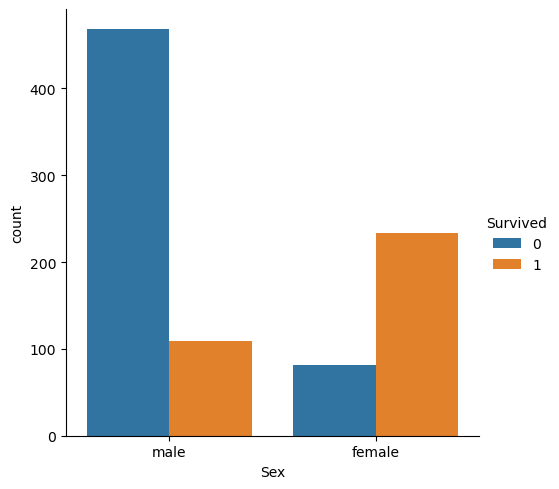

In [56]:
sns.catplot(x="Sex",hue="Survived",kind="count",data=titanic_cleaned)
print("Shakeeb Shaikh - TCS2526068")

In [17]:
titanic_cleaned.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [20]:
group1=titanic_cleaned.groupby(['Sex','Survived'])

In [21]:
gender_survived=group1.size().unstack()

Shakeeb Shaikh - TCS2526068


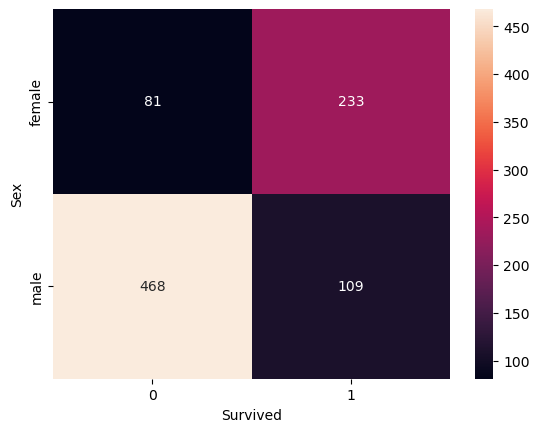

In [57]:
sns.heatmap(gender_survived,annot=True,fmt="d")
print("Shakeeb Shaikh - TCS2526068")

In [24]:
group2=titanic_cleaned.groupby(['Pclass','Survived'])

In [25]:
pclass_survived=group2.size().unstack()

Shakeeb Shaikh - TCS2526068


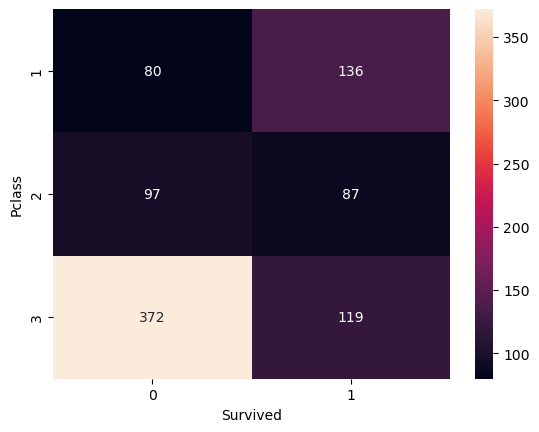

In [58]:
sns.heatmap(pclass_survived,annot=True,fmt="d")
print("Shakeeb Shaikh - TCS2526068")

Shakeeb Shaikh - TCS2526068


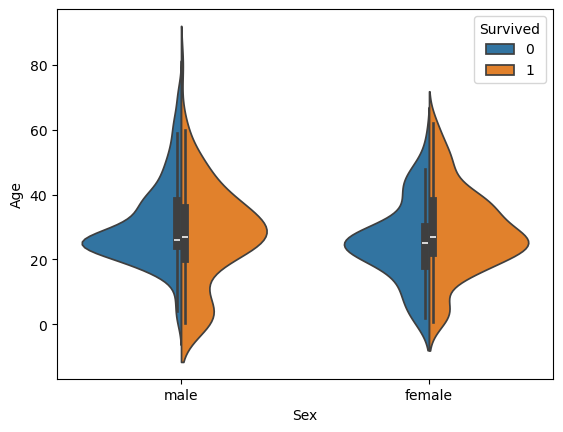

In [59]:
sns.violinplot(x="Sex",y="Age",hue="Survived",data=titanic_cleaned,split=True)
print("Shakeeb Shaikh - TCS2526068")

In [28]:
titanic_corr=titanic_cleaned.drop(['Sex','Embarked'],axis=1)

In [29]:
titanic_corr.corr(method="pearson")

,Survived,Pclass,Age,SibSp,Parch
Survived,1.000000,-0.338481,-0.050504,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.403858,0.083081,0.018443
Age,-0.050504,-0.403858,1.000000,-0.243452,-0.175799
SibSp,-0.035322,0.083081,-0.243452,1.000000,0.414838
Parch,0.081629,0.018443,-0.175799,0.414838,1.000000


Shakeeb Shaikh - TCS2526068


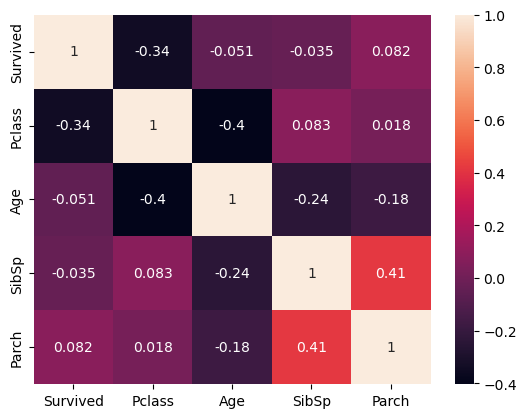

In [60]:
sns.heatmap(titanic_corr.corr(method="pearson"),annot=True,vmax=1)
print("Shakeeb Shaikh - TCS2526068")